In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,Model
from sklearn.metrics import confusion_matrix , classification_report

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train,y_train) , (x_test,y_test) = cifar10.load_data()
x_train.shape , y_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


((50000, 32, 32, 3), (50000, 1))

In [3]:
# Normalize the Data

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.1)])

In [4]:
# Bottleneck Block

def bottleneck_block(x,filters,stride=1):
    shortcut=x
    x=layers.Conv2D(
        filters,
        kernel_size=1,
        strides=stride,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal'
    )(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)
    x=layers.Conv2D(
        filters,
        kernel_size=3,
        strides=1,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal'
    )(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)
    x=layers.Conv2D(
        filters*4,
        kernel_size=1,
        strides=1,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal'
    )(x)
    x=layers.BatchNormalization()(x)
    if stride!=1 or shortcut.shape[-1]!=filters*4:
        shortcut=layers.Conv2D(
            filters*4,
            kernel_size=1,
            strides=stride,
            padding='same',
            use_bias=False,
            kernel_initializer='he_normal'
        )(shortcut)
        shortcut=layers.BatchNormalization()(shortcut)
    x=layers.Add()([x,shortcut])
    x=layers.Activation('relu')(x)
    return x

In [5]:
# Stage Creator

def make_stage(x,filters,blocks,stride):
    x=bottleneck_block(
        x,
        filters,
        stride
    )
    for _ in range(blocks-1):
        x=bottleneck_block(
            x,
            filters
        )
    return x

In [6]:
# Build Resnet
def build_resnet50():
    inputs=keras.Input(
        shape=(32,32,3)
    )
    x=data_augmentation(inputs)
    x=layers.Conv2D(
        64,
        kernel_size=3,
        strides=1,
        padding='same',
        use_bias=False,
        kernel_initializer='he_normal'
    )(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation('relu')(x)
    # [3,4,6,3]
    x=make_stage(
        x,
        64,
        3,
        1
    )
    x=make_stage(
        x,
        128,
        4,
        2
    )
    x=make_stage(
        x,
        256,
        6,
        2
    )
    x=make_stage(
        x,
        512,
        3,
        2
    )
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dropout(
        0.4
    )(x)
    outputs=layers.Dense(
        10,
        activation='softmax'
    )(x)
    model=Model(
        inputs,
        outputs,
        name='ResNet50'
    )
    return model

In [7]:
x_train.shape

(50000, 32, 32, 3)

In [8]:
model=build_resnet50()

model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,728 │ sequential[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,096 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     16,384 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     16,384 │ activation[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ add[0][0]       

 Total params: 23,573,962 (89.93 MB)

 Trainable params: 23,520,842 (89.72 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [9]:
lr_schedule=tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1,
    decay_steps=80000
)

In [10]:

optimizer=tf.keras.optimizers.SGD(
    learning_rate=lr_schedule,
    momentum=0.9,
)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
]

In [12]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 275s 636ms/step - accuracy: 0.1584 - loss: 3.1293 - val_accuracy: 0.2138 - val_loss: 2.2705
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 623ms/step - accuracy: 0.2683 - loss: 2.0650 - val_accuracy: 0.3285 - val_loss: 1.8858
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 623ms/step - accuracy: 0.3440 - loss: 1.8361 - val_accuracy: 0.3952 - val_loss: 1.7979
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 623ms/step - accuracy: 0.4010 - loss: 1.6694 - val_accuracy: 0.3730 - val_loss: 1.8488
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 243s 623ms/step - accuracy: 0.4422 - loss: 1.5404 - val_accuracy: 0.3877 - val_loss: 1.7916
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 623ms/step - accuracy: 0.4749 - loss: 1.4526 - val_accuracy: 0.4375 - val_loss: 1.6895
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 624ms/step - accuracy: 0.5049 - loss: 1.3747 - val_accuracy: 0.4475 - val_loss: 1.6492
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 623ms/step - accuracy: 0.5341 -

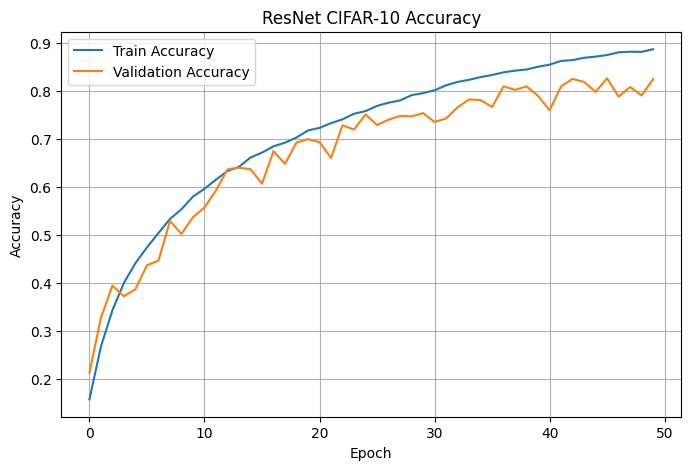

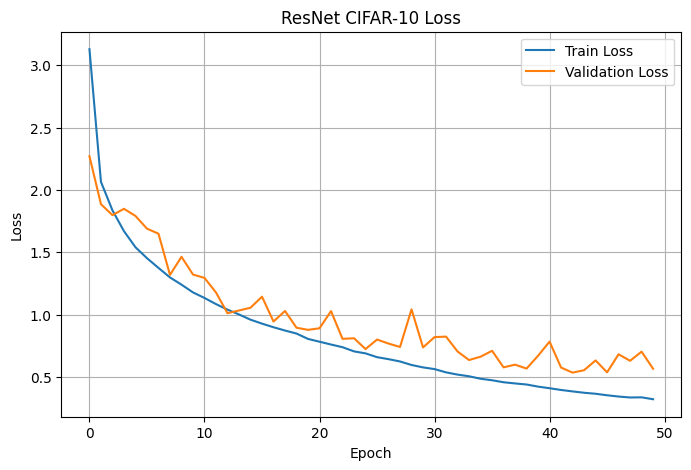

In [13]:
# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet CIFAR-10 Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_curve.png', bbox_inches='tight')
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet CIFAR-10 Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png', bbox_inches='tight')
plt.show()